<a href="https://colab.research.google.com/github/sisira-k27/gnss-multipath-classification/blob/main/gnss_multipath_analys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

['TOWC (s)', 'Week no', 'Receiver Nano Seconds (ns)', 'System Status-1', 'System Status-2', 'System Status-3', 'Block Count', 'No of tracked channels', 'Acquisition status word1', 'Acquisition status word2', 'Chan No-1', 'PRN-1', 'Channel Tracking Status-1', 'Doppler-1 (Hz)', 'C/NO-1 (dB-Hz)', 'Azimuth-1 (deg)', 'Elevation-1 (deg)', 'PR-1 (m)', 'DR-1 (m)', 'Reject Code-1', 'Lock Time-1 (s)', 'Iono Delay-1 (m)', 'Tropo Delay-1 (m)', 'Carrier Delay-1 (cycles)', 'Satellite X Position-1 (m)', 'Satellite Y Position-1 (m)', 'Satellite Z Position-1 (m)', 'Satellite X Velocity-1 (m/s)', 'Satellite Y Velocity-1 (m/s)', 'Satellite Z Velocity-1 (m/s)', 'Range Residuals-1 (m)', 'Satellite Clock Corrections-1 (ns)', 'Chan No-2', 'PRN-2', 'Channel Tracking Status-2', 'Doppler-2 (Hz)', 'C/NO-2 (dB-Hz)', 'Azimuth-2 (deg)', 'Elevation-2 (deg)', 'PR-2 (m)', 'DR-2 (m)', 'Reject Code-2', 'Lock Time-2 (s)', 'Iono Delay-2 (m)', 'Tropo Delay-2 (m)', 'Carrier Delay-2 (cycles)', 'Satellite X Position-2 (m)', '

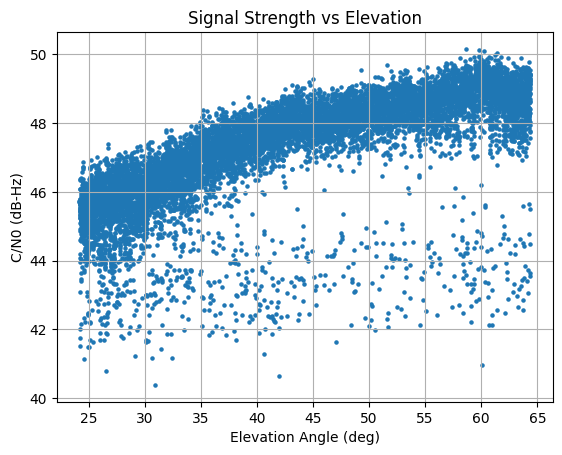

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("/SATB_L1.xlsx")

print(list(df.columns)) # Modified to print the full list of columns

plt.scatter(df['Elevation-1 (deg)'], df['C/NO-1 (dB-Hz)'], s=5)
plt.xlabel("Elevation Angle (deg)")
plt.ylabel("C/N0 (dB-Hz)")
plt.title("Signal Strength vs Elevation")
plt.grid()
plt.show()


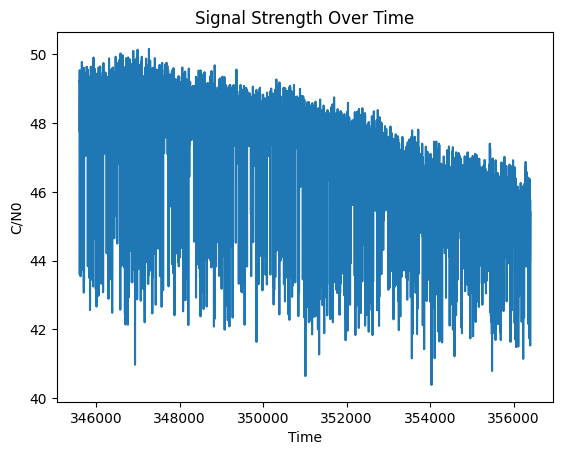

In [13]:
plt.plot(df['TOWC (s)'], df['C/NO-1 (dB-Hz)'])
plt.xlabel("Time")
plt.ylabel("C/N0")
plt.title("Signal Strength Over Time")
plt.show()

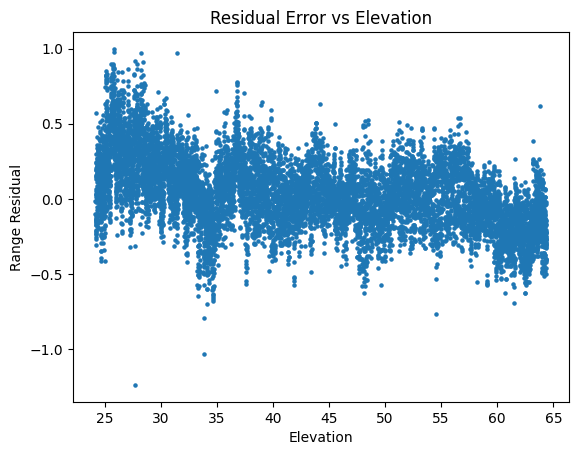

In [14]:
plt.scatter(df['Elevation-1 (deg)'], df['Range Residuals-1 (m)'], s=5)
plt.xlabel("Elevation")
plt.ylabel("Range Residual")
plt.title("Residual Error vs Elevation")
plt.show()

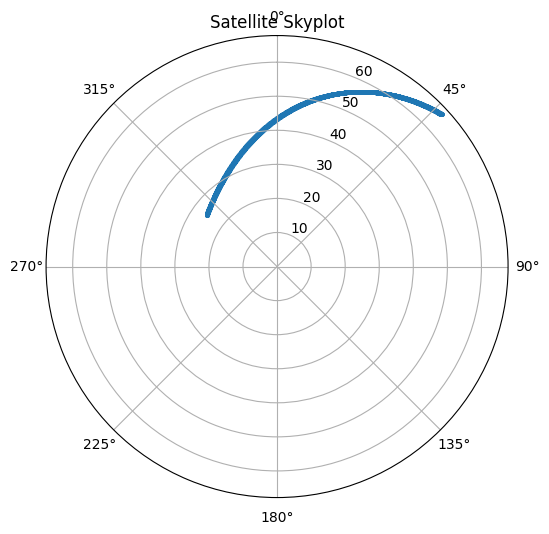

In [15]:
import numpy as np

az = np.deg2rad(df['Azimuth-1 (deg)'])
el = 90 - df['Elevation-1 (deg)']

plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.scatter(az, el, s=5)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.title("Satellite Skyplot")
plt.show()

In [18]:
import numpy as np

def classify(range_residuals_1_m):
    r = abs(range_residuals_1_m)

    if r < 0.3:
        return "LOS"
    elif r < 0.8:
        return "Multipath"
    else:
        return "NLOS"

df["Label"] = df["Range Residuals-1 (m)"].apply(classify)
print(df["Label"].value_counts())

Label
LOS          8556
Multipath    2205
NLOS           37
Name: count, dtype: int64


In [24]:
features = [
    "Elevation-1 (deg)",
    "C/NO-1 (dB-Hz)",
    "Doppler-1 (Hz)",
    ]

X = df[features]
y = df["Label"]

X = X.replace([np.inf, -np.inf], np.nan)

valid = X.notna().all(axis=1)

X = X[valid]
y = y[valid]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

for f, imp in zip(features, model.feature_importances_):
    print(f"{f}: {imp:.4f}")

              precision    recall  f1-score   support

         LOS       0.86      0.95      0.90      2567
   Multipath       0.63      0.39      0.48       662
        NLOS       0.50      0.09      0.15        11

    accuracy                           0.83      3240
   macro avg       0.66      0.48      0.51      3240
weighted avg       0.81      0.83      0.81      3240

Elevation-1 (deg): 0.3752
C/NO-1 (dB-Hz): 0.2775
Doppler-1 (Hz): 0.3473


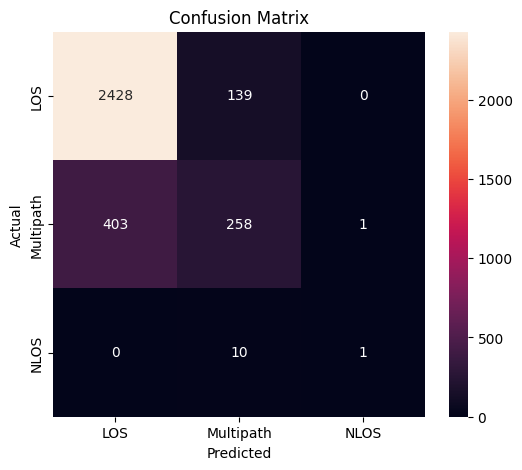

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [26]:
importance = model.feature_importances_

for name, score in zip(features, importance):
    print(f"{name}: {score:.4f}")

Elevation-1 (deg): 0.3752
C/NO-1 (dB-Hz): 0.2775
Doppler-1 (Hz): 0.3473
